In [1]:
import os
# proxy = 'http://127.0.0.1:7890'
proxy = 'http://10.20.38.38:7890'
os.environ['http_proxy'] = proxy
os.environ['https_proxy'] = proxy
os.environ["CUDA_VISIBLE_DEVICES"] = '2'


import numpy as np
import torch
import sys
import random
from PIL import Image
from scipy.special import softmax
import open_clip
from mne.time_frequency import psd_array_multitaper
import torch.nn.functional as F
import torch.nn as nn
from scipy.special import softmax
sys.path.append('/home/ldy/Closed_loop_optimizing')
sys.path.append('/home/ldy/Closed_loop_optimizing/model')
# from torchvision import transforms
from torchvision import models
from model.utils import load_model_encoder, generate_eeg, save_eeg_signal
import matplotlib.pyplot as plt
from model.custom_pipeline_low_level import Generator4Embeds
from model.modulation_utils import get_image_pool, load_vlmodel
from diffusers.utils import load_image
from IPython.display import display
import torchvision.transforms as transforms
from model.ATMS_retrieval import ATMS, get_eeg_features

import numpy as np
from util import save_eeg, get_gteeg
import einops
from model.pseudo_target_model import PseudoTargetModel
from huggingface_hub import hf_hub_download
from safetensors.torch import load_file
import logging
logging.getLogger("diffusers").setLevel(logging.WARNING)

device = "cuda" if torch.cuda.is_available() else "cpu"

/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pyt

In [2]:
feature_type = 'psd' #clip, psd

model_type = 'ViT-H-14'

vlmodel, preprocess_train, feature_extractor = open_clip.create_model_and_transforms(
    model_type, pretrained='laion2b_s32b_b79k', precision='fp32', device = device)
vlmodel.to(device)

generator = Generator4Embeds(device=device)
pipe = generator.pipe

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  7.89it/s]


In [ ]:
sub = 'sub-01'
fs = 250
# selected_channel_idxes = [3, 4, 5]   # 'O1', 'Oz', 'O2' only psd
selected_channel_idxes = slice(None)
# Set random seed (can be any integer, e.g. 42)
random.seed(43)
dnn = 'alexnet' #'alexnet' #,'cornet_s'    
if feature_type=='psd':        
    # selected_channel_idxes = [range(17)]   # 'O1', 'Oz', 'O2'
    # encoding_model_path = f'/mnt/dataset0/jiahua/eeg_encoding/results/{sub}/synthetic_eeg_data/encoding-end_to_end/dnn-alexnet/modeled_time_points-all/pretrained-False/lr-1e-05__wd-0e+00__bs-064/model_state_dict.pt'
    encoding_model_path = f'/mnt/dataset0/kyw/closed-loop/EEG-encoding/EEG_encoder/results/{sub}/synthetic_eeg_data/encoding-end_to_end/dnn-{dnn}/modeled_time_points-all/pretrained-True/lr-1e-05__wd-0e+00__bs-064/model_state_dict.pt'
    # target_eeg_path = f'/home/ldy/Closed_loop_optimizing/tjh/eeg_encoding/results/{sub}/synthetic_eeg_data/encoding-end_to_end/dnn-alexnet/modeled_time_points-all/pretrained-False/lr-1e-05__wd-0e+00__bs-064/gene_eeg/00183_tick_183.npy'
    # target_eeg_path = f'/home/ldy/Closed_loop_optimizing/tjh/eeg_encoding/results/{sub}/synthetic_eeg_data/encoding-end_to_end/dnn-alexnet/modeled_time_points-all/pretrained-False/lr-1e-05__wd-0e+00__bs-064/gene_eeg/00003_backscratcher_3.npy'
    # target_image_path = '/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00183_tick/tick_06s.jpg'
    # target_image_path = '/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00085_gondola/gondola_11s.jpg'
    # target_image_path = '/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00003_backscratcher/backscratcher_01b.jpg'
    # target_image_path = '/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00014_bike/bike_14s.jpg' 
    target_image_path = '/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00135_pie/pie_18s.jpg'  
     
    image_gt_folder = ['/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00014_bike/bike_14s.jpg'
                            ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00181_television/television_14n.jpg'
                            , '/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00177_t-shirt/t-shirt_13s.jpg'
                            ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00135_pie/pie_15s.jpg'
                            ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00131_pear/pear_13s.jpg']
    # target_eeg_embed = "/home/ldy/Closed_loop_optimizing/data/clip_embed/open_clip/00135_pie_eeg_embeds.pt"
    # target_eeg_embed = "/home/ldy/Closed_loop_optimizing/data/clip_embed/open_clip/00135_pie_image_embeds.pt"
    # target_image_path = image_gt_folder[3]
    # target_image_path = "/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00014_bike/bike_14s.jpg"    

    
elif feature_type=='clip':    
    # encoder_model_path = f'/mnt/dataset1/ldy/Workspace/Closed_loop_optimizing/kyw/closed-loop/EEG-encoding/EEG_encoder/results/{sub}/synthetic_eeg_data/encoding-end_to_end/dnn-{dnn}/modeled_time_points-all/pretrained-True/lr-1e-05__wd-0e+00__bs-064/model_state_dict.pt'
    encoding_model_path = f'/mnt/dataset0/kyw/closed-loop/EEG-encoding/EEG_encoder/results/{sub}/synthetic_eeg_data/encoding-end_to_end/dnn-{dnn}/modeled_time_points-all/pretrained-True/lr-1e-05__wd-0e+00__bs-064/model_state_dict.pt'
    gt_eeg_folder = f'/mnt/dataset0/kyw/closed-loop/syn_eeg_gt'
    image_gt_folder = ['/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00014_bike/bike_14s.jpg'
                            ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00181_television/television_14n.jpg'
                            , '/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00177_t-shirt/t-shirt_13s.jpg'
                            ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00135_pie/pie_15s.jpg'
                            ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00131_pear/pear_13s.jpg']
    # target_eeg_embed = "/home/ldy/Closed_loop_optimizing/data/clip_embed/open_clip/00135_pie_eeg_embeds.pt"
    target_eeg_embed = "/home/ldy/Closed_loop_optimizing/data/clip_embed/open_clip/00135_pie_image_embeds.pt"
    # target_image_path = image_gt_folder[3]
    target_image_path = "/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00135_pie/pie_18s.jpg"
    # f_encoder =  f"/mnt/dataset1/ldy/Workspace/Closed_loop_optimizing/kyw/closed-loop/sub_model/{sub}/diffusion_alexnet/pretrained_True/gene_gene/ATM_S_reconstruction_scale_0_1000_40.pth"
    f_encoder =  f"/mnt/dataset0/kyw/closed-loop/sub_model/{sub}/diffusion_alexnet/pretrained_True/gene_gene/ATM_S_reconstruction_scale_0_1000_40.pth"
    checkpoint = torch.load(f_encoder, map_location=device)

    eeg_model = ATMS()  # e.g., ATM_S_reconstruction_scale_0_1000 is the EEG model
    eeg_model.load_state_dict(checkpoint['eeg_model_state_dict'])
    

elif feature_type=='clip_img': 

    # encoder_model_path = f'/mnt/dataset1/ldy/Workspace/Closed_loop_optimizing/kyw/closed-loop/EEG-encoding/EEG_encoder/results/{sub}/synthetic_eeg_data/encoding-end_to_end/dnn-{dnn}/modeled_time_points-all/pretrained-True/lr-1e-05__wd-0e+00__bs-064/model_state_dict.pt'
    encoding_model_path = f'/mnt/dataset0/kyw/closed-loop/EEG-encoding/EEG_encoder/results/{sub}/synthetic_eeg_data/encoding-end_to_end/dnn-{dnn}/modeled_time_points-all/pretrained-True/lr-1e-05__wd-0e+00__bs-064/model_state_dict.pt'
    gt_eeg_folder = f'/mnt/dataset0/kyw/closed-loop/syn_eeg_gt'
    image_gt_folder = ['/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00014_bike/bike_14s.jpg'
                            ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00181_television/television_14n.jpg'
                            , '/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00177_t-shirt/t-shirt_13s.jpg'
                            ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00135_pie/pie_15s.jpg'
                            ,'/mnt/dataset0/ldy/datasets/THINGS_MEG/images_set/test_images/00131_pear/pear_13s.jpg']    
    target_image_embed = "/home/ldy/Closed_loop_optimizing/data/clip_embed/open_clip/00135_pie_image_embeds.pt"
    # target_image_path = image_gt_folder[3]
    target_image_path = "/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00135_pie/pie_18s.jpg"

    
image_set_path = '/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images'    
# image_set_path = '/mnt/dataset0/jiahua/closed-loop/imageset'
dir_name = os.path.basename(os.path.dirname(target_image_path))  # '00014_bike'
save_path = f"/home/ldy/Closed_loop_optimizing/outputs/heuristic_generation/{feature_type}"
os.makedirs(save_path, exist_ok=True)

In [4]:
def preprocess_image(image_path, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)), 
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    return image_tensor

def generate_eeg_from_image_paths(model_path, test_image_list, save_dir, device):
    synthetic_eegs = []
    model = load_model_encoder(model_path, device)
    for idx, image_path in enumerate(test_image_list):
        image_tensor = preprocess_image(image_path, device)
        synthetic_eeg = generate_eeg(model, image_tensor, device)
        synthetic_eegs.append(synthetic_eeg)
    synthetic_eegs = np.asarray(synthetic_eegs)
    return synthetic_eegs


def load_target_feature(encoding_model_path, target_image_path, fs, selected_channel_idxes, device):
    target_signal = generate_eeg_from_image_paths(encoding_model_path, [target_image_path], save_dir='', device=device)
    
    # if selected_channel_idxes==slice(None):        
    #     selected_target_signal = target_signal[:, :]
    # else:
    selected_target_signal = target_signal[selected_channel_idxes, :]                
    target_psd, _ = psd_array_multitaper(selected_target_signal, fs, adaptive=True, normalization='full', verbose=0)
    return torch.from_numpy(target_psd.flatten()).unsqueeze(0)

In [5]:
tar_feature_dir = f"/home/ldy/Closed_loop_optimizing/data/{feature_type}/"
os.makedirs(tar_feature_dir, exist_ok = True)

file_path = os.path.join(tar_feature_dir, f"{dir_name}_{feature_type}.pt")

     
if feature_type=='psd':
    target_feature = load_target_feature(encoding_model_path, target_image_path, fs, selected_channel_idxes, device)
    torch.save(target_feature, file_path)
    print(f"Files {file_path} saved!")    
elif feature_type=='clip':
    target_feature = torch.load(target_eeg_embed)
    torch.save(target_feature, file_path)
    print(f"Files {file_path} saved!")       
elif feature_type=='clip_img':
    target_feature = torch.load(target_image_embed)
    torch.save(target_feature, file_path)
    print(f"Files {file_path} saved!")           

/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/ldy/Closed_loop_optimizing/model/utils.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/b

Files /home/ldy/Closed_loop_optimizing/data/psd/00135_pie_psd.pt saved!


In [6]:
target_feature.shape

torch.Size([1, 2142])

In [7]:
test_images_path, _ = get_image_pool(image_set_path, cache_file='/home/ldy/Closed_loop_optimizing/data/200_images/image_paths_cache.pkl')
print(f"test_images_path {test_images_path}")

if target_image_path in test_images_path:
    test_images_path.remove(target_image_path)

Loading cached image paths from /home/ldy/Closed_loop_optimizing/data/200_images/image_paths_cache.pkl
test_images_path ['/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00001_aircraft_carrier/aircraft_carrier_06s.jpg', '/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00002_antelope/antelope_01b.jpg', '/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00003_backscratcher/backscratcher_01b.jpg', '/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00004_balance_beam/balance_beam_04s.jpg', '/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00005_banana/banana_09s.jpg', '/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00006_baseball_bat/baseball_bat_10s.jpg', '/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00007_basil/basil_05s.jpg', '/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00008_basketball/basketball_05s.jpg', '/mnt/dataset0/ldy/

In [8]:
len(test_images_path)

199

In [9]:



        
def generate_eeg_from_image(model_path, images, save_dir, device):
    synthetic_eegs = []
    model = load_model_encoder(model_path, device)
    for idx, image in enumerate(images):
        image_tensor = preprocess_generated_image(image, device)
        synthetic_eeg = generate_eeg(model, image_tensor, device)
        synthetic_eegs.append(synthetic_eeg)
        # category = category_list[idx]
        # save_eeg_signal(synthetic_eeg, save_dir, idx, category)
    return synthetic_eegs

def preprocess_generated_image(image, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)), 
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])    
    
    image_tensor = transform(image).unsqueeze(0).to(device)
    return image_tensor

def calculate_loss_from_eeg_path(eeg_path, target_feature, fs, selected_channel_idxes):
    # eeg = np.load(eeg_path, allow_pickle=True)
    # selected_eeg = eeg[selected_channel_idxes, :]
    # psd, _ = psd_array_multitaper(selected_eeg, fs, adaptive=True, normalization='full', verbose=0)
    # psd = torch.from_numpy(psd.flatten()).unsqueeze(0)
    # target_feature = torch.tensor(target_feature).view(1, 378)
    # loss_fn = nn.MSELoss()
    # loss = loss_fn(psd, target_feature)    
    loss = 0
    return loss

def calculate_loss(eeg, target_feature, fs, selected_channel_idxes):    
    # selected_eeg = eeg[selected_channel_idxes, :]
    # psd, _ = psd_array_multitaper(selected_eeg, fs, adaptive=True, normalization='full', verbose=0)
    # psd = torch.from_numpy(psd.flatten()).unsqueeze(0)
    # target_feature = torch.tensor(target_feature).view(1, 378)
    # loss_fn = nn.MSELoss()
    # loss = loss_fn(psd, target_feature)
    loss = 0
    return loss

def calculate_loss_clip_embed():
    loss = 0
    return loss

def calculate_loss_clip_embed_image():
    loss = 0
    return loss

In [10]:
def reward_function_from_eeg_path(eeg_path, target_feature, fs, selected_channel_idxes):
    eeg = np.load(eeg_path, allow_pickle=True)
    selected_eeg = eeg[selected_channel_idxes, :]
    psd, _ = psd_array_multitaper(selected_eeg, fs, adaptive=True, normalization='full', verbose=0)
    psd = torch.from_numpy(psd.flatten()).unsqueeze(0)
    return F.cosine_similarity(target_feature, psd).item()


def load_psd_from_eeg(target_signal, fs, selected_channel_idxes):
    selected_target_signal = target_signal[selected_channel_idxes, :]
    psd_feature, _ = psd_array_multitaper(selected_target_signal, fs, adaptive=True, normalization='full', verbose=0)
    return torch.from_numpy(psd_feature.flatten()).unsqueeze(0)

def reward_function(eeg, target_feature, fs, selected_channel_idxes):    
    selected_eeg = eeg[selected_channel_idxes, :]
    psd, _ = psd_array_multitaper(selected_eeg, fs, adaptive=True, normalization='full', verbose=0)
    psd = torch.from_numpy(psd.flatten()).unsqueeze(0)
    return F.cosine_similarity(target_feature, psd).item()

  

def reward_function_clip_embed_image(pil_image, target_feature):
    """
    Generate EEG signals corresponding to a given image and compute similarity with groundtruth
    :param image: Image feature vector [1024]
    :param groundtruth_eeg: Groundtruth feature vector [1024]
    :return: Similarity between EEG signal and groundtruth
    """    
    tensor_images = [preprocess_train(pil_image)]    
    with torch.no_grad():
        img_embeds = vlmodel.encode_image(torch.stack(tensor_images).to(device))      
    
    similarity = torch.nn.functional.cosine_similarity(img_embeds.to(device), target_feature.to(device))
    
    similarity = (similarity + 1) / 2    
    # print(similarity)
    return similarity.item()

def reward_function_clip_embed(eeg, eeg_model, target_feature, sub, dnn):
    """
    Generate EEG signals corresponding to a given image and compute similarity with groundtruth
    :param image: Image feature vector [1024]
    :param groundtruth_eeg: Groundtruth feature vector [1024]
    :return: Similarity between EEG signal and groundtruth
    """    
    eeg_feature = get_eeg_features(eeg_model, torch.tensor(eeg).unsqueeze(0), device, sub)    
    similarity = torch.nn.functional.cosine_similarity(eeg_feature.to(device), target_feature.to(device))
    # cos_sim = F.softmax(cos_sim)
    similarity = (similarity + 1) / 2
    
    # print(similarity)
    return similarity.item(), eeg_feature


In [11]:
class HeuristicGenerator:
    def __init__(self, pipe, vlmodel, preprocess_train, device="cuda"):
        self.pipe = pipe
        self.vlmodel = vlmodel
        self.preprocess_train = preprocess_train
        self.device = device
        
        # Hyperparameters
        self.batch_size = 32
        self.alpha = 80
        self.total_steps = 15
        self.max_inner_steps = 10
        self.num_inference_steps = 8
        self.guidance_scale = 0.0
        self.dimension = 1024
        self.self_improvement_ratio = 0.5
        self.reward_scaling_factor = 100
        self.initial_step_size = 30
        self.decay_rate = 0.1
        self.generate_batch_size = 1
        self.save_per = 5
        
        # Initialize components
        self.pseudo_target_model = PseudoTargetModel(dimension=self.dimension, noise_level=1e-4).to(self.device)
        self.generator = torch.Generator(device=device).manual_seed(0)
        
        # Load IP adapter
        self.pipe.load_ip_adapter(
            "h94/IP-Adapter", subfolder="sdxl_models", 
            weight_name="ip-adapter_sdxl_vit-h.bin", 
            torch_dtype=torch.bfloat16)
        self.pipe.set_ip_adapter_scale(0.5)
    
    def reward_function_embed(self, embed1, embed2):
        """
        Compute reward based on cosine similarity between CLIP embeddings
        
        Args:
            embed1: First set of embeddings (batch_size, embedding_dim)
            embed2: Second set of embeddings (batch_size, embedding_dim)
            
        Returns:
            Normalized similarity scores in [0, 1] range
        """
        # Compute cosine similarity (range [-1, 1])
        cosine_sim = F.cosine_similarity(embed1, embed2, dim=1)
        
        # Normalize to [0, 1] range
        normalized_sim = (cosine_sim + 1) / 2
        
        return normalized_sim
    
    def latents_to_images(self, latents):
        shift_factor = self.pipe.vae.config.shift_factor if self.pipe.vae.config.shift_factor else 0.0
        latents = (latents / self.pipe.vae.config.scaling_factor) + shift_factor
        images = self.pipe.vae.decode(latents, return_dict=False)[0]
        images = self.pipe.image_processor.postprocess(images.detach())
        return images
    
    def x_flatten(self, x):
        return einops.rearrange(x, '... C W H -> ... (C W H)', 
                              C=self.pipe.unet.config.in_channels, 
                              W=self.pipe.unet.config.sample_size, 
                              H=self.pipe.unet.config.sample_size)
    
    def x_unflatten(self, x):
        return einops.rearrange(x, '... (C W H) -> ... C W H', 
                              C=self.pipe.unet.config.in_channels, 
                              W=self.pipe.unet.config.sample_size, 
                              H=self.pipe.unet.config.sample_size)
    
    def get_norm(self, epsilon):
        return self.x_flatten(epsilon).norm(dim=-1)[:,:,None,None,None]
    
    def merge_images_grid(self, image_grid):
        rows = len(image_grid)
        cols = len(image_grid[0])
        img_width, img_height = image_grid[0][0].size
        merged_image = Image.new('RGB', (cols * img_width, rows * img_height))
        
        for row_idx, row in enumerate(image_grid):
            for col_idx, img in enumerate(row):
                merged_image.paste(img, (col_idx * img_width, row_idx * img_height))
        
        return merged_image
        
    def generate(self, data_x, data_y, tar_image_embed, prompt='', save_path=None, start_embedding=None):
        # Add model data
        # print(f"data_x {data_x[0].shape}")
        # print(f"data_y {data_y}")
        
        
        # Initialize noise
        epsilon = torch.randn(self.num_inference_steps+1, self.generate_batch_size, 
                            self.pipe.unet.config.in_channels, 
                            self.pipe.unet.config.sample_size, 
                            self.pipe.unet.config.sample_size, 
                            device=self.device, generator=self.generator)
        
        epsilon_init = epsilon.clone()
        epsilon_init_norm = self.get_norm(epsilon_init)
        all_images = []
        
        # Initialize pseudo target
        if start_embedding is not None:
            pseudo_target = start_embedding.expand(self.generate_batch_size, self.dimension).to(self.device)
        else:
            pseudo_target = torch.randn(self.generate_batch_size, self.dimension, device=self.device, generator=self.generator)
        
        for step in range(self.total_steps):
            # Generate latents and images
            latents = self.pipe(
                [prompt]*self.generate_batch_size,
                ip_adapter_image_embeds=[pseudo_target.unsqueeze(0).type(torch.bfloat16).to(self.device)],
                latents=epsilon[0].type(torch.bfloat16),
                given_noise=epsilon[1:].type(torch.bfloat16),
                output_type="latent",
                num_inference_steps=self.num_inference_steps,
                guidance_scale=self.guidance_scale,
                eta=1.0,
            ).images
            
            images = self.latents_to_images(latents)         
            
            data_x, data_y = self.pseudo_target_model.get_model_data()   
            # print(f"data_y.size(0) {data_y.size(0)}")
            if data_y.size(0) < 50: #w/o optimization 
                return images
            
            image_inputs = torch.stack([self.preprocess_train(img) for img in images])
            
            # Get image features and calculate similarity
            with torch.no_grad():
                image_features = self.vlmodel.encode_image(image_inputs.to(self.device)) 
            
            # Use the class method instead of external function
            # scaled_similarity = self.reward_function_embed(
            #     image_features, 
            #     tar_image_embed.expand(self.generate_batch_size, tar_image_embed.size(-1))
            # ) 
            
            # Update pseudo target
            step_size = self.initial_step_size / (1 + self.decay_rate * step)
            # print(f"image_features {image_features.shape}")
            # print(f"image_features {len(image_features)}")

            pseudo_target, _ = self.pseudo_target_model.estimate_pseudo_target(image_features, step_size=step_size) #batchsize, hidden_dim
            
            # Save images periodically
            if step % self.save_per == 0:
                # print(f"scaled_similarity {scaled_similarity}")
                all_images.append(images)
            
            del latents
        # Save merged image if path provided
        if save_path:
            merged_image = self.merge_images_grid(all_images)
            merged_image.save(save_path)
        
        return images

In [12]:

def fusion_image_to_images(Generator, img_embeds, rewards, device, save_path, scale):        
        # Randomly select two different indices
    idx1, idx2 = random.sample(range(len(img_embeds)), 2)
    # Get corresponding embedding vectors and add batch dimension
    embed1, embed2 = img_embeds[idx1].unsqueeze(0), img_embeds[idx2].unsqueeze(0)
    embed_len = embed1.size(1)
    start_idx = random.randint(0, embed_len - scale - 1)
    end_idx = start_idx + scale
    temp = embed1[:, start_idx:end_idx].clone()
    embed1[:, start_idx:end_idx] = embed2[:, start_idx:end_idx]
    embed2[:, start_idx:end_idx] = temp
    # print(f"chosen_images {len(chosen_images)}")
    # print(f"rewards {len(rewards)}")
    generated_images = []        
    # with torch.no_grad():         
    images = Generator.generate(img_embeds.to(device), torch.tensor(rewards).to(device), target_feature, prompt='', save_path=None, start_embedding=embed1)
    # image = generator.generate(embed1)
    generated_images.extend(images)
    # print(f"type(images) {type(images)}")
    images = Generator.generate(img_embeds.to(device), torch.tensor(rewards).to(device), target_feature, prompt='', save_path=None, start_embedding=embed2)
    # image = generator.generate(embed2)
    generated_images.extend(images)
    
    return generated_images
    

In [13]:
def select_from_image_paths(probabilities, similarities, losses, sample_image_paths, synthetic_eegs, device, size):
    chosen_indices = np.random.choice(len(probabilities), size=size, replace=False, p=probabilities)
    # print(f"sample_image_paths {len(sample_image_paths)}")
    # print(f"chosen_indices  {chosen_indices}")
    
    chosen_similarities = [similarities[idx] for idx in chosen_indices.tolist()] 
    chosen_losses = [losses[idx] for idx in chosen_indices.tolist()]    
    chosen_images = [Image.open(sample_image_paths[i]).convert("RGB") for i in chosen_indices.tolist()]        
    chosen_eegs = [synthetic_eegs[idx] for idx in chosen_indices.tolist()]
    return chosen_similarities, chosen_losses, chosen_images, chosen_eegs


def select_from_images(probabilities, similarities, losses, images_list, eeg_list, size):
    chosen_indices = np.random.choice(len(similarities), size=size, replace=False, p=probabilities)
    # print(f"eeg_list {len(eeg_list)}")
    # print(f"chosen_indices  {chosen_indices}")    
    chosen_similarities = [similarities[idx] for idx in chosen_indices.tolist()] 
    chosen_losses = [losses[idx] for idx in chosen_indices.tolist()]
    chosen_images = [images_list[idx] for idx in chosen_indices.tolist()]
    chosen_eegs = [eeg_list[idx] for idx in chosen_indices.tolist()]
    return chosen_similarities, chosen_losses, chosen_images, chosen_eegs


In [14]:

def get_prob_random_sample(test_images_path, model_path, save_path, fs, device, selected_channel_idxes, processed_paths, target_feature, size):
    available_paths = [path for path in test_images_path if path not in processed_paths]    
    sample_image_paths = sorted(random.sample(available_paths, 10))
    # print(f"sample_image_paths {sample_image_paths}")
    sample_image_name = []
    pil_images = []
    for sample_image_path in sample_image_paths:
        filename = os.path.basename(sample_image_path).split('.')[0]
        sample_image_name.append(filename)    
        pil_images.append(Image.open(sample_image_path).convert("RGB"))
    synthetic_eegs = generate_eeg_from_image_paths(model_path, sample_image_paths, save_path, device)
    
    similarities = []
    
    losses = []
    for idx, eeg in enumerate(synthetic_eegs):  
        if feature_type =='psd':
            cs = reward_function(eeg, target_feature, fs, selected_channel_idxes)
            loss = calculate_loss(eeg, target_feature, fs, selected_channel_idxes)
        elif feature_type =='clip':
            cs, eeg_feature = reward_function_clip_embed(eeg, eeg_model, target_feature, sub, dnn)
            loss = calculate_loss_clip_embed()
        elif feature_type =='clip_img':
            cs = reward_function_clip_embed_image(pil_images[idx], target_feature)
            loss = calculate_loss_clip_embed_image()    
        # print(cs, type(cs))
        similarities.append(cs)        
        losses.append(loss)
        
    probabilities = softmax(similarities)
    
    
    chosen_similarities, chosen_losses, chosen_images, chosen_eegs = select_from_image_paths(probabilities, similarities, losses, sample_image_paths, synthetic_eegs, device, size)
    
    return chosen_similarities, chosen_losses, chosen_images, chosen_eegs

In [15]:

def visualize_top_images(images, similarities, save_folder, iteration):
    """
    Display selected images in order of similarity using matplotlib
    :param image_paths: List of image paths
    :param similarities: List of similarity values for each image
    """
    # Combine image paths and similarities, sort by similarity in descending order
    image_similarity_pairs = sorted(zip(images, similarities), key=lambda x: x[1], reverse=True)
    
    # Unpack sorted image paths and similarities
    sorted_images, sorted_similarities = zip(*image_similarity_pairs)

    # Plot images
    fig, axes = plt.subplots(1, len(sorted_images), figsize=(15, 5))
    for i, image in enumerate(sorted_images):
        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(f'Similarity: {sorted_similarities[i]:.4f}', fontsize=8)  # Display similarity
    plt.show()
    
    os.makedirs(save_folder, exist_ok=True)  # Create folder if it doesn't exist
    save_path = os.path.join(save_folder, f"visualization_iteration_{iteration}.png")
    fig.savefig(save_path, bbox_inches='tight', dpi=300)  # Save image file
    print(f"Visualization saved to {save_path}")

In [16]:
def compute_embed_similarity(img_feature, all_features):
    """
    Compute cosine similarity between a given image and all other images (result in 0-1 range)
    :param img_feature: Feature vector of the selected image [D] or [1, D]
    :param all_features: Feature vectors of all images [N, D]
    :return: Cosine similarities [N] (range 0-1)
    """
    # Ensure inputs are float type
    img_feature = img_feature.float()
    all_features = all_features.float()
    
    # Ensure feature vector is 2D [1, D]
    if img_feature.dim() == 1:
        img_feature = img_feature.unsqueeze(0)
    
    # Check for NaN/Inf values
    assert torch.isfinite(img_feature).all(), "img_feature contains NaN/Inf values"
    assert torch.isfinite(all_features).all(), "all_features contains NaN/Inf values"    
    
    # Normalize feature vectors
    img_feature = F.normalize(img_feature, p=2, dim=1)
    all_features = F.normalize(all_features, p=2, dim=1)
    
    # Compute cosine similarity [-1,1]
    cosine_sim = torch.mm(all_features, img_feature.t()).squeeze(1)
    
    # Convert to [0,1] range
    cosine_sim = (cosine_sim + 1) / 2  # Method 1: linear scaling
    # cosine_sim = torch.sigmoid(cosine_sim)  # Method 2: sigmoid
    
    # Ensure numerical stability
    cosine_sim = torch.clamp(cosine_sim, 0.0, 1.0)
    
    return cosine_sim

/tmp/ipykernel_3262692/3639858447.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_set_img_embeds = torch.load("/mnt/dataset1/ldy/Workspace/FLORA/data_preparing/ViT

Created new experiment directory: /home/ldy/Closed_loop_optimizing/outputs/heuristic_generation/exp205


/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loop 1/10


/tmp/ipykernel_3262692/3639858447.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Generator.pseudo_target_model.add_model_data(torch.tensor(tensor_loop_sample_ten_embeds).to(device), (-torch.tensor(loop_reward_ten) * Generator.reward_scaling_factor).to(device))
/tmp/ipykernel_3262692/3639858447.py:188: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Generator.pseudo_target_model.add_model_data(torch.tensor(tensor_loop_sample_ten_embeds).to(device), (-torch.tensor(loop_reward_ten) * Generator.reward_scaling_factor).to(device))


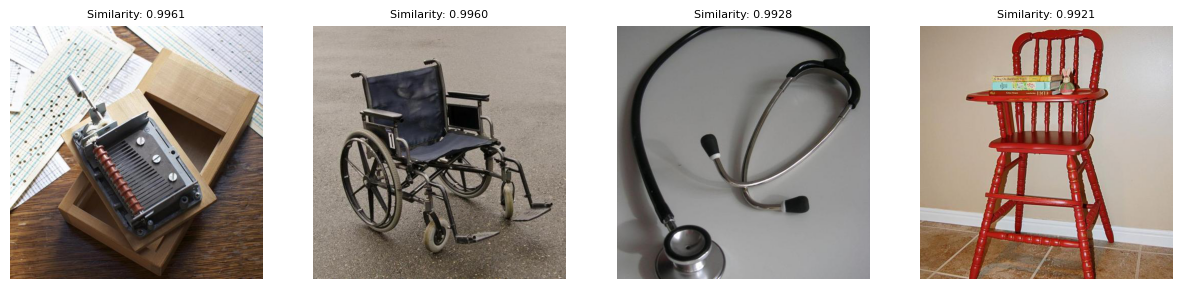

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/heuristic_generation/visualization_iteration_0.png
Loop 2/10


100%|██████████| 8/8 [00:00<00:00, 12.64it/s]


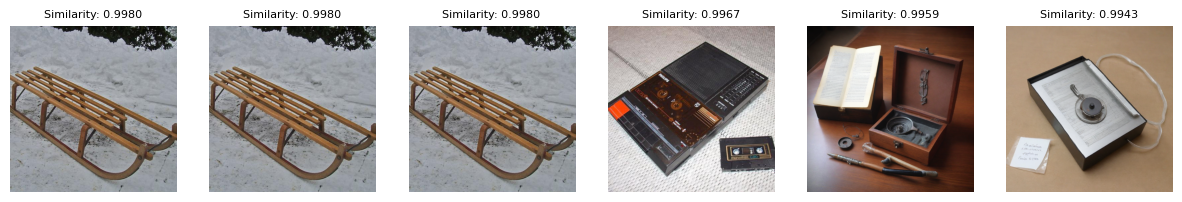

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/heuristic_generation/visualization_iteration_1.png
0.9979686709674693 0.9960938411297546 0.0018748298377146977
Loop 3/10


100%|██████████| 8/8 [00:00<00:00, 12.64it/s]


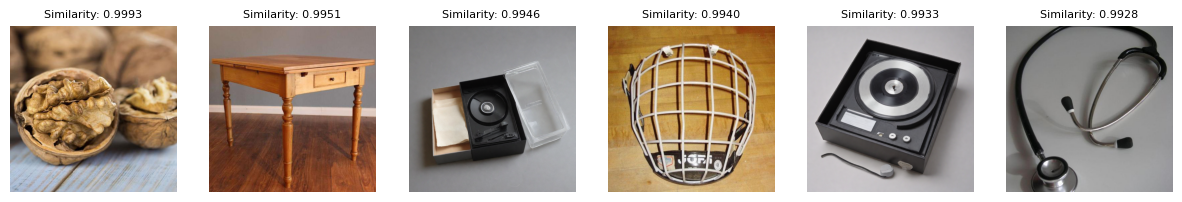

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/heuristic_generation/visualization_iteration_2.png
0.9993349613516816 0.9979686709674693 0.0013662903842123209
Loop 4/10


100%|██████████| 8/8 [00:00<00:00, 12.60it/s]


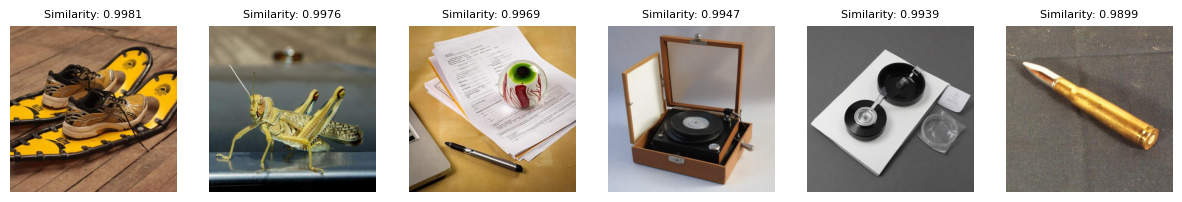

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/heuristic_generation/visualization_iteration_3.png
Loop 5/10


100%|██████████| 8/8 [00:00<00:00, 12.51it/s]


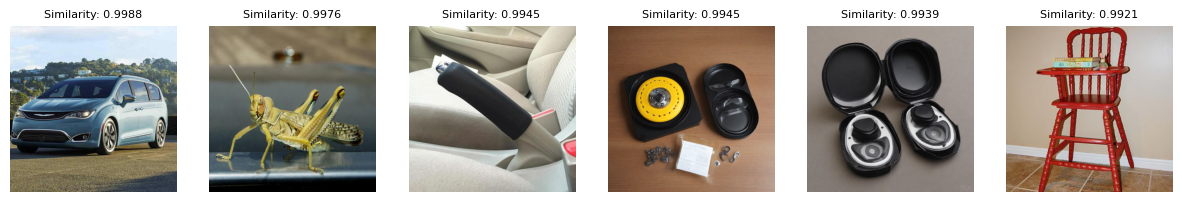

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/heuristic_generation/visualization_iteration_4.png
Loop 6/10


100%|██████████| 8/8 [00:00<00:00, 12.51it/s]


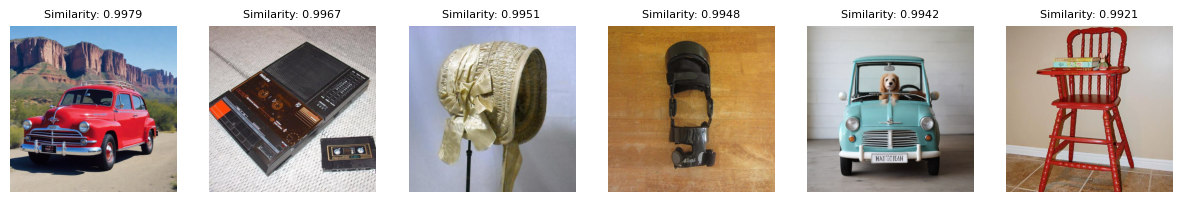

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/heuristic_generation/visualization_iteration_5.png
Loop 7/10


100%|██████████| 8/8 [00:00<00:00, 12.55it/s]


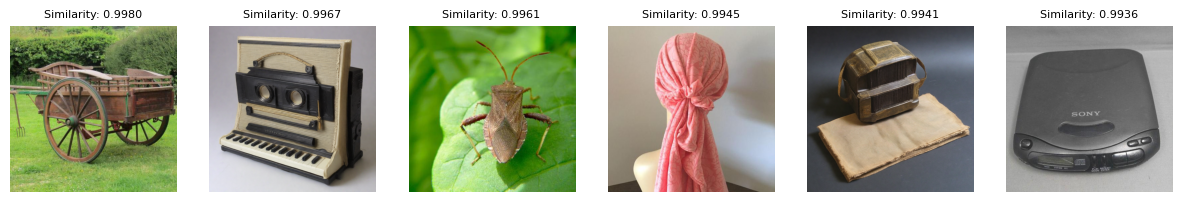

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/heuristic_generation/visualization_iteration_6.png
Loop 8/10


100%|██████████| 8/8 [00:00<00:00, 12.54it/s]


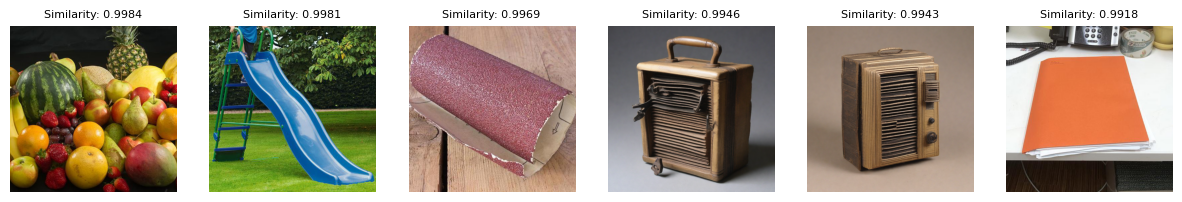

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/heuristic_generation/visualization_iteration_7.png
Loop 9/10


100%|██████████| 8/8 [00:00<00:00, 12.37it/s]
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /opt/conda/conda-bld/pytorch_1728945388038/work/aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
100%|██████████| 8/8 [00:00<00:00, 12.35it/s]


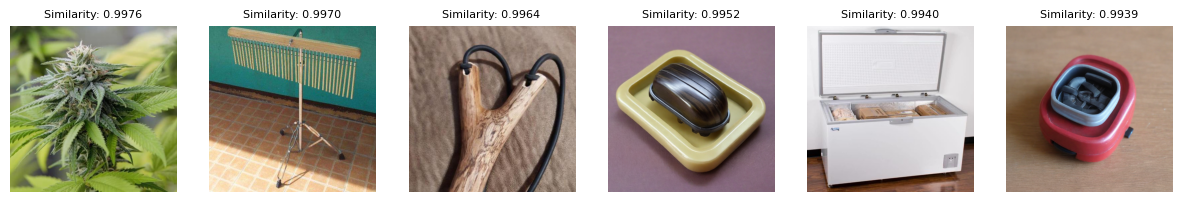

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/heuristic_generation/visualization_iteration_8.png
Loop 10/10


100%|██████████| 8/8 [00:00<00:00, 12.20it/s]


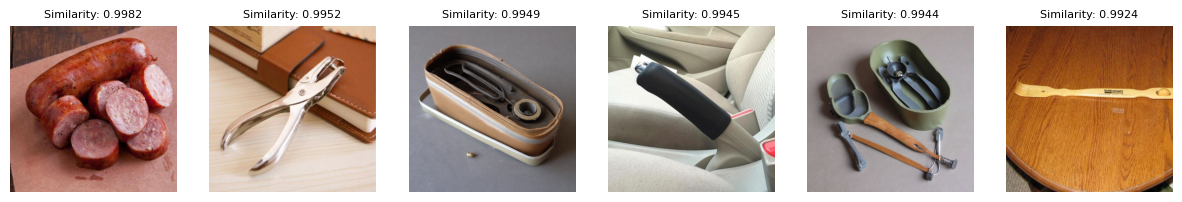

Visualization saved to /home/ldy/Closed_loop_optimizing/outputs/heuristic_generation/visualization_iteration_9.png


In [17]:
num_loops = 10

processed_paths = set()

all_chosen_rewards = []
all_chosen_losses = []
all_chosen_images = []
all_chosen_eegs = []

history_cs = []
history_eeg = []
history_loss = []
fit_images = []
fit_eegs = []
fit_rewards = []
fit_losses = []
save_folder = f'/home/ldy/Closed_loop_optimizing/outputs/heuristic_generation'
plots_save_folder = '/home/ldy/Closed_loop_optimizing/plots/Interactive_search'
test_set_img_embeds = torch.load("/mnt/dataset1/ldy/Workspace/FLORA/data_preparing/ViT-H-14_features_test.pt")['img_features'].cpu()

# test_set_img_embeds = torch.load("/home/ldy/Closed_loop_optimizing/data/clip_embed/open_clip/600_image_embeds.pt").cpu()
# Ensure the base directory exists
os.makedirs(save_folder, exist_ok=True)
# Find existing experiment directories
existing_exps = [d for d in os.listdir(save_folder) if d.startswith('exp') and d[3:].isdigit()]
if existing_exps:
    # Get the maximum experiment number
    max_num = max(int(exp[3:]) for exp in existing_exps)
    new_exp_num = max_num + 1
else:
    # If no existing experiments, start from 1
    new_exp_num = 1
# Create new experiment directory
new_exp_dir = os.path.join(save_folder, f'exp{new_exp_num}')
os.makedirs(new_exp_dir, exist_ok=True)
print(f"Created new experiment directory: {new_exp_dir}")


Generator = HeuristicGenerator(pipe, vlmodel, preprocess_train, device=device)

for t in range(num_loops):
    print(f"Loop {t + 1}/{num_loops}")
    round_save_path = os.path.join(save_path, f'loop{t + 1}')
    loop_sample_ten = []
    loop_reward_ten = []
    loop_eeg_ten = []
    loop_loss_ten = []
    os.makedirs(save_path, exist_ok=True)

    if t == 0:
        first_ten = os.path.join(round_save_path, 'first_ten')
        os.makedirs(first_ten, exist_ok=True)
        chosen_rewards, chosen_losses, chosen_images, chosen_eegs = get_prob_random_sample(test_images_path, 
                                                                                    encoding_model_path, 
                                                                                    first_ten, 
                                                                                    fs, device, 
                                                                                    selected_channel_idxes,
                                                                                    processed_paths, 
                                                                                    target_feature,
                                                                                    size=4)
        
        loop_sample_ten.extend(chosen_images)
        loop_eeg_ten.extend(chosen_eegs)
        loop_reward_ten.extend(chosen_rewards)
        loop_loss_ten.extend(chosen_losses)
        
        tensor_loop_sample_ten = [preprocess_train(i) for i in loop_sample_ten]    
        with torch.no_grad():
            tensor_loop_sample_ten_embeds = vlmodel.encode_image(torch.stack(tensor_loop_sample_ten).to(device))        
        Generator.pseudo_target_model.add_model_data(torch.tensor(tensor_loop_sample_ten_embeds).to(device), (-torch.tensor(loop_reward_ten) * Generator.reward_scaling_factor).to(device))        
                
    else:                            
        # loop_sample_ten.extend(fit_images)
        # loop_eeg_ten.extend(fit_eegs)
        # loop_reward_ten.extend(fit_rewards)
        # loop_loss_ten.extend(fit_losses)
        
        tensor_fit_images = [preprocess_train(i) for i in fit_images]    
        with torch.no_grad():
            img_embeds = vlmodel.encode_image(torch.stack(tensor_fit_images).to(device))    
        generated_images = fusion_image_to_images(Generator, img_embeds, fit_rewards, device, round_save_path, 512)                                    
        synthetic_eegs = generate_eeg_from_image(encoding_model_path, generated_images, round_save_path, device)        
        
        loop_sample_ten.extend(generated_images)
        loop_eeg_ten.extend(synthetic_eegs)
                
        for idx, eeg in enumerate(synthetic_eegs):  
            if feature_type =='psd':
                cs = reward_function(eeg, target_feature, fs, selected_channel_idxes)
                loss = calculate_loss(eeg, target_feature, fs, selected_channel_idxes)
            elif feature_type =='clip':
                cs, eeg_feature = reward_function_clip_embed(eeg, eeg_model, target_feature, sub, dnn)
                loss = calculate_loss_clip_embed()
            elif feature_type =='clip_img':
                cs = reward_function_clip_embed_image(generated_images[idx], target_feature)
                loss = calculate_loss_clip_embed_image()                
            loop_reward_ten.append(cs)
            loop_loss_ten.append(loss)    
        

        greedy_images = []
        # with torch.no_grad():
        #     loop_img_embeds = vlmodel.encode_image(torch.stack([preprocess_train(i) for i in loop_sample_ten]).to(device))
        
        # Define the top K count to randomly select from
        TOP_K = 10  # Adjust this value as needed

        for img_embed in img_embeds:      
            available_indices = []
            # available_paths = []            
            for i, path in enumerate(test_images_path):
                if path not in processed_paths:
                    available_indices.append(i)
                    # available_paths.append(path)
            
            sample_image_paths =[]            
            available_features = test_set_img_embeds[available_indices]
            
            cosine_similarities = compute_embed_similarity(img_embed.to(device), available_features.to(device))    
            sorted_available_indices = np.argsort(cosine_similarities.cpu())
            
            # Get top K indices (K with highest similarity)
            top_indices = sorted_available_indices[-TOP_K:]
            
            # Randomly select one from the top K
            selected_idx = np.random.choice(top_indices)
            # print(f"available_paths {len(available_paths)}")            
            # print(f"available_indices {available_indices}")
            # print(f"selected_idx {selected_idx}")
            greedy_image = Image.open(test_images_path[selected_idx]).convert("RGB")
            greedy_images.append(greedy_image)
            sample_image_paths.append(test_images_path[selected_idx])
                
            processed_paths.update(sample_image_paths)   
            
        synthetic_eegs = generate_eeg_from_image(encoding_model_path, greedy_images, round_save_path, device)            
        
        loop_sample_ten.extend(greedy_images)
        loop_eeg_ten.extend(synthetic_eegs)
                
        for idx, eeg in enumerate(synthetic_eegs):  
            if feature_type =='psd':
                cs = reward_function(eeg, target_feature, fs, selected_channel_idxes)
                loss = calculate_loss(eeg, target_feature, fs, selected_channel_idxes)
            elif feature_type =='clip':
                cs, eeg_feature = reward_function_clip_embed(eeg, eeg_model, target_feature, sub, dnn)
                loss = calculate_loss_clip_embed()
            elif feature_type =='clip_img':
                cs = reward_function_clip_embed_image(greedy_images[idx], target_feature)
                loss = calculate_loss_clip_embed_image()    
            loop_reward_ten.append(cs)
            loop_loss_ten.append(loss)        
        

        loop_probabilities = softmax(loop_reward_ten)    
        chosen_rewards, chosen_losses, chosen_images, chosen_eegs = select_from_images(loop_probabilities, loop_reward_ten, loop_loss_ten, loop_sample_ten, loop_eeg_ten, size=4)        
        
        # Sort the four lists by chosen_rewards in descending order
        combined = list(zip(chosen_rewards, chosen_losses, chosen_images, chosen_eegs))
        combined.sort(reverse=True, key=lambda x: x[0])  # Sort by rewards in descending order

        # Unpack the sorted data
        chosen_rewards, chosen_losses, chosen_images, chosen_eegs = zip(*combined)

        # Convert results back to lists (since zip returns tuples)
        chosen_rewards = list(chosen_rewards)
        chosen_losses = list(chosen_losses)
        chosen_images = list(chosen_images)
        chosen_eegs = list(chosen_eegs)


    fit_images = chosen_images
    fit_eegs = chosen_eegs
    fit_rewards = chosen_rewards
    fit_losses = chosen_losses
    
                
    all_chosen_rewards.extend(chosen_rewards)
    all_chosen_losses.extend(chosen_losses)
    all_chosen_images.extend(chosen_images)
    all_chosen_eegs.extend(chosen_eegs)
    
    # print(f"chosen_images {len(chosen_images)}")
    # print(f"chosen_rewards {chosen_rewards}")
    tensor_loop_sample_ten = [preprocess_train(i) for i in loop_sample_ten]    
    with torch.no_grad():
        tensor_loop_sample_ten_embeds = vlmodel.encode_image(torch.stack(tensor_loop_sample_ten).to(device))        
    Generator.pseudo_target_model.add_model_data(torch.tensor(tensor_loop_sample_ten_embeds).to(device), (-torch.tensor(loop_reward_ten) * Generator.reward_scaling_factor).to(device))        
    visualize_top_images(loop_sample_ten, loop_reward_ten, save_folder, t)

    # max_similarity = max(loop_reward_ten)
    
    # max_index = loop_reward_ten.index(max_similarity)
    # # corresponding_loss = chosen_losses[max_index]
    
    
    # if len(history_cs) == 0:
    #     history_cs.append(max_similarity)
    #     # history_loss.append(corresponding_loss) 
    # else:
    #     max_history = max(history_cs)
    #     if max_similarity > max_history:
    #         history_cs.append(max_similarity)
    #         # history_loss.append(corresponding_loss)
    #     else:
    #         history_cs.append(max_history)
    #         # history_loss.append(history_loss[-1])

    # if len(history_cs) >= 2:
    #     if history_cs[-1] != history_cs[-2]:
    #         diff = abs(history_cs[-1] - history_cs[-2])
    #         print(history_cs[-1], history_cs[-2], diff)
    #         if diff <= 1e-4:
    #             print("The difference is within 10e-4, stopping.")
    #             break

    max_similarity = max(loop_reward_ten)
    max_index = loop_reward_ten.index(max_similarity)
    corresponding_eeg = loop_eeg_ten[max_index]  # Get corresponding EEG data

    if len(history_cs) == 0:
        history_cs.append(max_similarity)
        history_eeg.append(corresponding_eeg)  # Also record EEG data
    else:
        max_history = max(history_cs)
        if max_similarity > max_history:
            history_cs.append(max_similarity)
            history_eeg.append(corresponding_eeg)  # Record new EEG data
        else:
            history_cs.append(max_history)
            history_eeg.append(history_eeg[-1])  # Keep previous EEG data

    if len(history_cs) >= 2:
        if history_cs[-1] != history_cs[-2]:
            diff = abs(history_cs[-1] - history_cs[-2])
            print(history_cs[-1], history_cs[-2], diff)
            if diff <= 1e-4:
                print("The difference is within 10e-4, stopping.")
                break

In [18]:
history_cs

[0.9960938411297546,
 0.9979686709674693,
 0.9993349613516816,
 0.9993349613516816,
 0.9993349613516816,
 0.9993349613516816,
 0.9993349613516816,
 0.9993349613516816,
 0.9993349613516816,
 0.9993349613516816]

chosen_rewards 4
all_chosen_losses 40
all_chosen_images 40
all_chosen_eegs 40


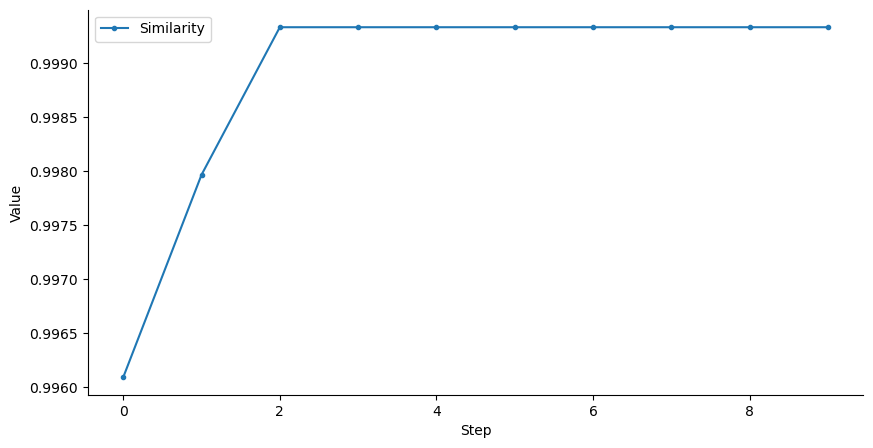

In [19]:
print(f"chosen_rewards {len(chosen_rewards)}")
print(f"all_chosen_losses {len(all_chosen_losses)}")
print(f"all_chosen_images {len(all_chosen_images)}")
print(f"all_chosen_eegs {len(all_chosen_eegs)}")

plt.figure(figsize=(10, 5))
plt.plot(history_cs, marker='o', markersize=3, label='Similarity')
# plt.plot(history_cs, marker='o', markersize=5, label='Similarity')
# plt.plot(history_loss, marker='x', markersize=3, label='Loss')
plt.xlabel('Step')
plt.ylabel('Value')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend() 
path = os.path.join(save_path, 'similarities.jpg')
plt.savefig(path)
plt.show()


In [20]:
# history_eeg.shape

# selected_channel_idxes

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def select_closed_loop_eeg_results(history_eeg, history_cs):
    """
    从history_eeg中找到对应history_cs最大值的EEG，并绘制选定通道的时间序列
    
    参数:
        history_eeg: list of numpy arrays, 每个EEG形状为(17, 250)
        history_cs: list of floats, 与history_eeg对应的cs值
        selected_channel_idxes: list of int, 要绘制的通道索引
    """
    # 检查输入有效性
    if len(history_eeg) != len(history_cs):
        raise ValueError("history_eeg和history_cs的长度必须相同")
    if not history_eeg:
        raise ValueError("输入列表不能为空")
    
    # 找到最大cs值对应的索引
    max_cs_idx = np.argmax(history_cs)
    max_cs = history_cs[max_cs_idx]
    selected_eeg = history_eeg[max_cs_idx]
    
    print(f"最大CS值: {max_cs}, 对应的EEG索引: {max_cs_idx}")

    return selected_eeg    

# 调用函数
closed_loop_eeg_result = select_closed_loop_eeg_results(history_eeg, history_cs)

最大CS值: 0.9993349613516816, 对应的EEG索引: 2


In [22]:
random_image_paths = []
# random_seeds = [11, 21, 31, 41, 51] 
random_seeds = [11]
for seed in random_seeds:
    random.seed(seed)
    if test_images_path: #确保列表不为空
        chosen_path = random.choice(test_images_path)
        random_image_paths.append(chosen_path)
    else:
        print("Warning: test_images_path is empty. Cannot sample.")
        break

print(f"test_5_image_paths: {random_image_paths}")

# 1. 预处理图像
random_selected_image_tensor = preprocess_image(random_image_paths[0], device)
encoding_model = load_model_encoder(encoding_model_path, device)
# 2. 从图像合成EEG
random_selected_eeg_result = generate_eeg(encoding_model, random_selected_image_tensor, device) # numpy array


test_5_image_paths: ['/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/images_set/test_images/00116_modem/modem_04s.jpg']


/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/ldy/Closed_loop_optimizing/model/utils.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/b

In [23]:

offline_image_path = '/home/ldy/Closed_loop_optimizing/server/offline_image.png'
offline_image_tensor = preprocess_image(offline_image_path, device)
offline_eeg_result = generate_eeg(encoding_model, offline_image_tensor, device) 


In [24]:
target_eeg_path = f'/home/ldy/Closed_loop_optimizing/tjh/eeg_encoding/results/sub-01/synthetic_eeg_data/encoding-end_to_end/dnn-alexnet/modeled_time_points-all/pretrained-False/lr-1e-05__wd-0e+00__bs-064/gene_eeg/00135_pie_135.npy'
target_eeg_result = np.load(target_eeg_path, allow_pickle=True)

In [25]:
print(f"closed_loop_eeg_result {closed_loop_eeg_result.shape}")
print(f"random_selected_eeg_result {random_selected_eeg_result.shape}")
print(f"target_eeg_result {target_eeg_result.shape}")
print(f"offline_eeg_result {offline_eeg_result.shape}")

closed_loop_eeg_result (17, 250)
random_selected_eeg_result (17, 250)
target_eeg_result (17, 250)
offline_eeg_result (17, 250)


In [26]:

# 1. 预处理图像
random_selected_image_tensor = preprocess_image(random_image_paths[0], device)
encoding_model = load_model_encoder(encoding_model_path, device)
# 2. 从图像合成EEG
random_selected_eeg_result = generate_eeg(encoding_model, random_selected_image_tensor, device) # numpy array

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Optional

# def plot_multiple_eeg_conditions(
#     eeg_data: Dict[str, np.ndarray],
#     selected_channel_idxes: List[int],
#     channel_names: List[str],
#     condition_colors: Optional[Dict[str, str]] = None,
#     condition_styles: Optional[Dict[str, str]] = None,
#     sampling_rate: int = 250,
#     linewidth: float = 1.0,
#     figsize: tuple = (12, 8)
# ):
#     """
#     Plot EEG time series for multiple conditions with a single legend at the top
    
#     Parameters:
#         eeg_data: Dictionary where keys are condition names and values are EEG data arrays
#         selected_channel_idxes: List of channel indices to plot
#         channel_names: List of all channel names corresponding to the EEG data
#         condition_colors: Optional dictionary mapping conditions to colors
#         condition_styles: Optional dictionary mapping conditions to line styles
#         sampling_rate: Sampling rate in Hz (default 250)
#         linewidth: Line width for plotting (default 1.0)
#         figsize: Figure size (default (12, 8))
#     """
    
#     conditions = list(eeg_data.keys())
    
#     # if condition_colors is None:
#     #     condition_colors = {
#     #         'Random': 'blue',
#     #         'Offline': 'green',
#     #         'Closed-loop': 'gray',
#     #     }
#     #     for cond in conditions:
#     #         if cond not in condition_colors and cond != 'Target':
#     #             condition_colors[cond] = np.random.rand(3,)
    
#     if condition_styles is None:
#         condition_styles = {}
#         for cond in conditions:
#             condition_styles[cond] = '-'
    
#     if 'Target' in conditions:
#         condition_colors['Target'] = 'black'
#         condition_styles['Target'] = '--'
    
#     n_channels = len(selected_channel_idxes)
    
#     # Create a figure with subplots, leaving space at the top for the legend
#     fig = plt.figure(figsize=figsize)
    
#     # Create a grid for subplots with extra space at the top
#     gs = plt.GridSpec(n_channels + 1, 1, height_ratios=[0.5] + [1]*n_channels)
    
#     # Create axes for the legend (top) and EEG plots (bottom)
#     legend_ax = fig.add_subplot(gs[0])
#     axes = [fig.add_subplot(gs[i+1]) for i in range(n_channels)]
    
#     # Hide the legend axis (we'll just use it for the legend)
#     legend_ax.axis('off')
    
#     # Create proxy artists for the legend
#     legend_lines = []
#     for cond in conditions:
#         line = plt.Line2D([0], [0], 
#                          color=condition_colors[cond],
#                          linestyle=condition_styles[cond],
#                          linewidth=linewidth,
#                          label=cond)
#         legend_lines.append(line)
    
#     # Add the legend to the top axis
#     legend_ax.legend(handles=legend_lines, 
#                     loc='center', 
#                     ncol=len(conditions), 
#                     fontsize=20,
#                     frameon=False)
    
#     time = np.arange(eeg_data[conditions[0]].shape[1]) / sampling_rate
    
#     for i, (ch_idx, ax) in enumerate(zip(selected_channel_idxes, axes)):
#         channel_name = channel_names[ch_idx]
        
#         for cond in conditions:
#             eeg = eeg_data[cond]
#             ax.plot(
#                 time*1000, 
#                 eeg[ch_idx, :], 
#                 color=condition_colors[cond],
#                 linestyle=condition_styles[cond],
#                 linewidth=linewidth,
#             )
#             ax.spines['right'].set_visible(False)
#             ax.spines['top'].set_visible(False)
        
#         ax.tick_params(axis='y', labelsize=20)
#         ax.spines['bottom'].set_linewidth(2)
#         ax.spines['left'].set_linewidth(2)            
#         ax.set_title(f'Channel {channel_name} (Index {ch_idx})', pad=10, fontsize=22)
#         ax.set_xticks([])
#         # ax.set_ylabel('Amplitude', fontsize=20)
    
#     plt.tight_layout()
#     return fig, axes


def plot_multiple_eeg_conditions(
    eeg_data: Dict[str, np.ndarray],
    selected_channel_idxes: List[int],
    channel_names: List[str],
    condition_colors: Optional[Dict[str, str]] = None,
    condition_styles: Optional[Dict[str, str]] = None,
    sampling_rate: int = 250,
    linewidth: float = 1.0,
    figsize: tuple = (12, 8)
):
    """
    Plot EEG time series for multiple conditions with a single legend at the top
    
    Parameters:
        eeg_data: Dictionary where keys are condition names and values are EEG data arrays
        selected_channel_idxes: List of channel indices to plot
        channel_names: List of all channel names corresponding to the EEG data
        condition_colors: Optional dictionary mapping conditions to colors
        condition_styles: Optional dictionary mapping conditions to line styles
        sampling_rate: Sampling rate in Hz (default 250)
        linewidth: Line width for plotting (default 1.0)
        figsize: Figure size (default (12, 8))
    """
    
    conditions = list(eeg_data.keys())
    
    if condition_styles is None:
        condition_styles = {}
        for cond in conditions:
            condition_styles[cond] = '-'
    
    if 'Target' in conditions:
        condition_colors['Target'] = 'black'
        condition_styles['Target'] = '--'
    
    n_channels = len(selected_channel_idxes)
    
    # Create a figure with subplots, leaving space at the top for the legend
    fig = plt.figure(figsize=figsize)
    
    # Create a grid for subplots with extra space at the top
    gs = plt.GridSpec(n_channels + 1, 1, height_ratios=[0.5] + [1]*n_channels)
    
    # Create axes for the legend (top) and EEG plots (bottom)
    legend_ax = fig.add_subplot(gs[0])
    axes = [fig.add_subplot(gs[i+1]) for i in range(n_channels)]
    
    # Hide the legend axis (we'll just use it for the legend)
    legend_ax.axis('off')
    
    # Create proxy artists for the legend
    legend_lines = []
    for cond in conditions:
        line = plt.Line2D([0], [0], 
                         color=condition_colors[cond],
                         linestyle=condition_styles[cond],
                         linewidth=linewidth,
                         label=cond)
        legend_lines.append(line)
    
    # Add the legend to the top axis
    legend_ax.legend(handles=legend_lines, 
                    loc='center', 
                    ncol=len(conditions), 
                    fontsize=20,
                    frameon=False)
    
    time = np.arange(eeg_data[conditions[0]].shape[1]) / sampling_rate
    total_time_ms = time[-1] * 1000
    
    for i, (ch_idx, ax) in enumerate(zip(selected_channel_idxes, axes)):
        channel_name = channel_names[ch_idx]
        
        # Add gray dashed line at y=0
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        
        for cond in conditions:
            eeg = eeg_data[cond]
            ax.plot(
                time*1000, 
                eeg[ch_idx, :], 
                color=condition_colors[cond],
                linestyle=condition_styles[cond],
                linewidth=linewidth,
            )
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
        
        ax.tick_params(axis='y', labelsize=20)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)            
        ax.set_title(f'Channel {channel_name} (Index {ch_idx})', pad=10, fontsize=22)
        
        # Set x-ticks at every 1/5 of the data length
        # 手动设置固定的刻度（例如 0, 125, 250, 375, 500ms）
        xticks = np.arange(0, 501, 125)  # 0, 125, 250, 375, 500ms
        ax.set_xticks(xticks)
        ax.set_xticklabels([f'{x:.0f} ms' for x in xticks], fontsize=16)
        
        # Only show x-axis labels on the bottom plot
        if i != n_channels - 1:
            ax.set_xticklabels([])
    
    plt.tight_layout()
    plt.savefig("/home/ldy/Closed_loop_optimizing/plots/Heuristic_generation/timeseries.png", dpi=300)
    return fig, axes


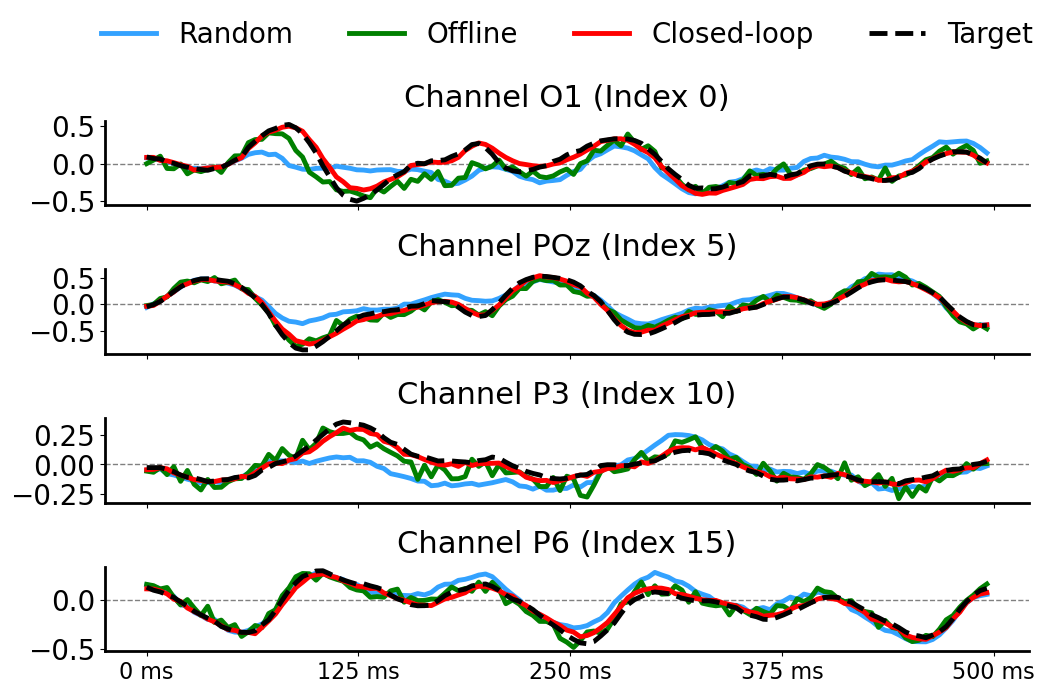

In [28]:

# Channel names
selected_channels = ['O1', 'Oz', 'O2', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 
                    'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8']

# Prepare data (replace with your actual data)
eeg_data = {        
    'Random': random_selected_eeg_result[:, :125],
    'Offline': offline_eeg_result[:, :125],
    'Closed-loop': closed_loop_eeg_result[:, :125],
    'Target': target_eeg_result[:, :125]
}

# Custom colors
# custom_colors = {
#     'Random': '#FF5733',  # orange
#     'Offline': '#33A2FF',  # blue
#     'Closed-loop': '#A1A1A1',  # gray
#     'Target': 'black'  # black for target
# }

# Custom colors
custom_colors = {
    'Random': '#33A2FF',  # orange
    'Offline': 'green',  # green
    'Closed-loop': '#FF0000',  # magenta (品红)
    'Target': 'black'  # black for target
}

# Call the function with channel names
fig, axes = plot_multiple_eeg_conditions(
    eeg_data=eeg_data,
    selected_channel_idxes=[0, 5, 10, 15],  # Corresponding to O1, POz, P1, P6
    channel_names=selected_channels,
    condition_colors=custom_colors,
    sampling_rate=250,
    linewidth=3.5,
    figsize=(11, 7)
)

plt.show()